# Setup

In [1]:
import numpy as np
from astropy import constants as const, units as u
import matplotlib.pyplot as plt
import h5py

In [2]:
import sys
sys.path.append('./')
from functions import *

In [3]:
def S_OMS(freqs):
    # Aoms = 7.9e-12  # <-- Sangria
    # Aoms = 15e-12
    Aoms = 12e-12
    return (Aoms * 2*np.pi*freqs/const.c.value)**2 * (1 + (2e-3/freqs)**4)

def S_acc(freqs):
    # Aacc = 2.4e-15  # <-- Sangria
    # Aacc = 3e-15
    Aacc = 2.4e-15
    return (Aacc / (2*np.pi*freqs*const.c.value))**2 * (1 + (0.4e-3/freqs)**2) * (1 + (freqs/8e-3)**4)

def S_X20_EQarm(freqs, L):
    omega = 2*np.pi*freqs
    Soms = S_OMS(freqs)
    Sacc = S_acc(freqs)
    return 64 * np.sin(2*omega*L/const.c.value)**2 * np.sin(omega*L/const.c.value)**2 * ( Soms + (3+np.cos(2*omega*L/const.c.value))*Sacc )



# Frequency range for the LISA sensitivity curve
freqs_sens = np.logspace(-4,-1,200)


Larm = 2.5e9

In [4]:
# Set the normalization convention
norm = "backward"


Tlisa  = 1*u.year.to(u.s)
f_lisa = 1/Tlisa

# Load Data

In [5]:
# Load the data and look at the keys
hf = h5py.File('./Figure_4/LISAsim_data_files/lisasim1.h5', 'r')
# hf = h5py.File('./Figure_4/LISAsim_data_files/lisasim2.h5', 'r')
# hf = h5py.File"('./Figure_4/LISAsim_data_files/lisasim3.h5', 'r')

print("H5 file keys: ", hf.keys())

H5 file keys:  <KeysViewHDF5 ['chirping', 'monochromatic', 'simulation_metadata', 'times']>


In [6]:
# Store the data in arrays, then close the h5 file
data_sim   = dict(zip( [i for i in hf['simulation_metadata'].keys()], [hf['simulation_metadata/'+i][()] for i in hf['simulation_metadata'].keys()] ))
data_mono  = hf['monochromatic'][:]
data_chirp = hf['chirping'][:]
data_t     = hf['times'][:]
hf.close()

In [7]:
print("\nStarting data array shape = ", data_mono.shape)
print("\nSimulation Meta-Data: ")
[print(key, " = ", data_sim[key]) for key in data_sim.keys()];


Starting data array shape =  (3471336,)

Simulation Meta-Data: 
A  =  2.9435722714303155e-22
K  =  11105.34637922211
M1  =  1.1930459224188305e+30
M2  =  1.1930459224188305e+30
Mc  =  1.038606799799853e+30
Mp  =  1.8981245973360506e+29
R  =  6.171355162982734e+19
T_p  =  315576.0
Tobs  =  315576000.0
dfgw0  =  7.168806922737828e-16
dt  =  90.90909090909092
epsilon  =  0.05845011599607014
f_p  =  3.168808781402895e-06
fgw0  =  0.005
fs  =  0.011
gw_beta  =  0
gw_lambda  =  0
inc  =  1.5707963267948966
iota  =  0
phi0  =  0
phi0_p  =  0
psi  =  0


In [8]:
df = 1/data_sim['Tobs']

# Calculate DFT and Fourier Transforms

In [9]:
# Compute the one-dimensional discrete Fourier Transform for real input (output is still complex!)
# (and cut first f=0 frequency from the dataset)
mono_DFT  = np.fft.rfft(data_mono, norm=norm)[1:]  
chirp_DFT = np.fft.rfft(data_chirp, norm=norm)[1:]  

# Return the Discrete Fourier Transform sample frequencies and their spacing
# (and cut first f=0 frequency from the dataset)
freqs = np.fft.rfftfreq(data_t.size, data_sim['dt'])[1:]

In [10]:
# convert the DFT data to the FT data

mono_FT  = DFT_to_FT(mono_DFT, freqs, data_sim['dt'], data_t[0], data_t.size, norm)
chirp_FT = DFT_to_FT(chirp_DFT, freqs, data_sim['dt'], data_t[0], data_t.size, norm)

mono_FT.shape

(1735668,)

# SNR Calculations

In [11]:
print("TOTAL SNR calculation")
print("mono  = ", SNR(mono_FT.reshape(1,-1), S_X20_EQarm(freqs, Larm).reshape(1,1,-1), df))
print("chirp = ", SNR(chirp_FT.reshape(1,-1), S_X20_EQarm(freqs, Larm).reshape(1,1,-1), df))


TOTAL SNR calculation
mono  =  567.5295105662073
chirp =  567.457348807901


In [12]:
N = 3  # Number of df spacings around the peak
n = 1  # Which sideband

In [13]:
condition_mono_carrier = (data_sim['fgw0'] - N*df < freqs) & (freqs < data_sim['fgw0'] + N*df)

# freqs[np.where(condition_mono_carrier)]

In [14]:
condition_mono_n_side = (data_sim['fgw0'] + n*data_sim['f_p'] - N*df < freqs) & (freqs < data_sim['fgw0'] + n*data_sim['f_p'] + N*df)

# freqs[np.where(condition_mono_n_side)]

In [15]:
condition_chirp_carrier = (data_sim['fgw0'] + 1/2*data_sim['dfgw0']*data_sim['Tobs'] - N*df < freqs) & (freqs < data_sim['fgw0'] + 1/2*data_sim['dfgw0']*data_sim['Tobs'] + N*df)

# freqs[np.where(condition_chirp_carrier)]

In [16]:
condition_chirp_n_side = (data_sim['fgw0'] + n*data_sim['f_p'] + 1/2*data_sim['dfgw0']*data_sim['Tobs'] - N*df < freqs) & (freqs < data_sim['fgw0'] + n*data_sim['f_p'] + 1/2*data_sim['dfgw0']*data_sim['Tobs'] + N*df)

# freqs[np.where(condition_chirp_n_side)]

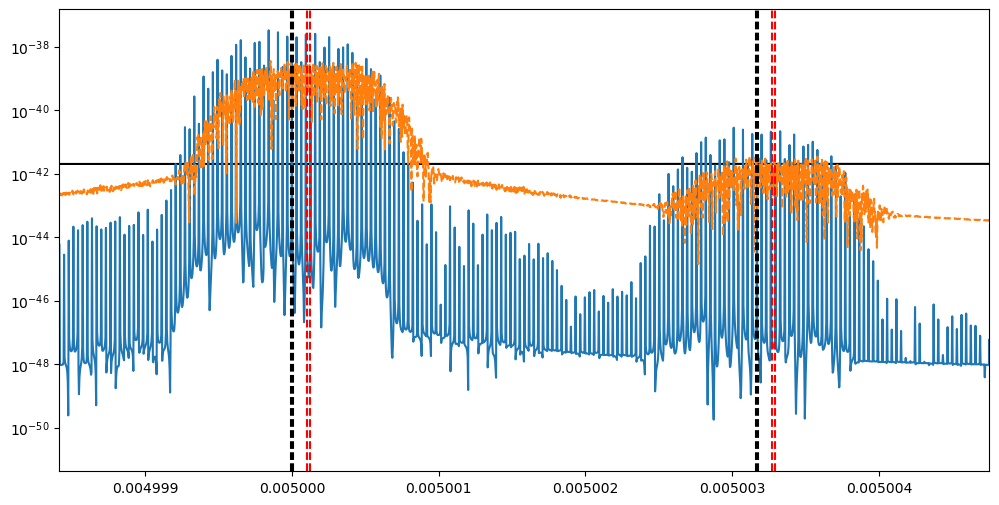

In [17]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

PSD_mono  = PSD_1s_fromFT(mono_FT, data_sim['Tobs']).real
PSD_chirp = PSD_1s_fromFT(chirp_FT, data_sim['Tobs']).real

ax.semilogy(freqs, S_X20_EQarm(freqs, Larm), color='k')
ax.semilogy(freqs, PSD_mono,        label='Monochromatic')
ax.semilogy(freqs, PSD_chirp, '--', label='Chirping')

ax.axvline(freqs[np.where(condition_mono_carrier)][0], color='k', linestyle='--')
ax.axvline(freqs[np.where(condition_mono_carrier)][-1], color='k', linestyle='--')
ax.axvline(freqs[np.where(condition_mono_n_side)][0], color='k', linestyle='--')
ax.axvline(freqs[np.where(condition_mono_n_side)][-1], color='k', linestyle='--')

ax.axvline(freqs[np.where(condition_chirp_carrier)][0], color='r', linestyle='--')
ax.axvline(freqs[np.where(condition_chirp_carrier)][-1], color='r', linestyle='--')
ax.axvline(freqs[np.where(condition_chirp_n_side)][0], color='r', linestyle='--')
ax.axvline(freqs[np.where(condition_chirp_n_side)][-1], color='r', linestyle='--')

# number of sidebands to the left/right for the plotting window
left_n  = 0.5
right_n = 1.5

ax.set_xlim([data_sim['fgw0']-left_n*data_sim['f_p'], data_sim['fgw0']+right_n*data_sim['f_p']])
plt.show()

## Monochromatic Signal

In [18]:
mono_carrier_SNR = SNR(mono_FT[np.where(condition_mono_carrier)].reshape(1,-1), S_X20_EQarm(freqs[np.where(condition_mono_carrier)], Larm).reshape(1,1,-1), df)
mono_n_side_SNR  = SNR(mono_FT[np.where(condition_mono_n_side)].reshape(1,-1), S_X20_EQarm(freqs[np.where(condition_mono_n_side)], Larm).reshape(1,1,-1), df)

print("Carrier SNR  = {0:0.5f}".format(mono_carrier_SNR))
print("Sideband SNR = {0:0.5f}".format(mono_n_side_SNR))

Carrier SNR  = 60.63906
Sideband SNR = 1.71944


In [19]:
print("Numerical Ratio = {0:0.5f}".format(mono_n_side_SNR/mono_carrier_SNR))
print("Analytic Ratio  = {0:0.5f}".format(np.abs(sp.jv(n,data_sim['epsilon']))/sp.jv(0,data_sim['epsilon'])))


Numerical Ratio = 0.02836
Analytic Ratio  = 0.02924


## Chirping Signal

In [20]:
chirp_carrier_SNR = SNR(chirp_FT[np.where(condition_chirp_carrier)].reshape(1,-1), S_X20_EQarm(freqs[np.where(condition_chirp_carrier)], Larm).reshape(1,1,-1), df)
chirp_n_side_SNR  = SNR(chirp_FT[np.where(condition_chirp_n_side)].reshape(1,-1), S_X20_EQarm(freqs[np.where(condition_chirp_n_side)], Larm).reshape(1,1,-1), df)

print("Carrier SNR  = {0:0.5f}".format(chirp_carrier_SNR))
print("Sideband SNR = {0:0.5f}".format(chirp_n_side_SNR))

Carrier SNR  = 95.11677
Sideband SNR = 2.92885


In [21]:
print("Numerical Ratio = {0:0.5f}".format(chirp_n_side_SNR/chirp_carrier_SNR))
print("Analytic Ratio  = {0:0.5f}".format(np.abs(sp.jv(n,data_sim['epsilon']))/sp.jv(0,data_sim['epsilon'])))


Numerical Ratio = 0.03079
Analytic Ratio  = 0.02924
